# Imports

In [86]:
import os
import sys
from pathlib import Path
from IPython.display import display
import pandas as pd
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("data_and_annotation exists:", (PROJECT_ROOT / "src" / "data_and_annotation.py").exists())
print("__init__.py exists:", (PROJECT_ROOT / "src" / "__init__.py").exists())



Current working directory: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER
src exists: True
data_and_annotation exists: True
__init__.py exists: True


In [87]:
from src.data_and_annotation import (
    prepare_part2_data,
    label_distribution,
    topic_distribution
)

print("Imported functions successfully.")

Imported functions successfully.


In [88]:
BASE_DIR = "."
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH = os.path.join(BASE_DIR, "metadata.json")
DATA_DIR = os.path.join(BASE_DIR, "data")

print("cleaned exists:", os.path.exists(CLEANED_PATH))
print("metadata exists:", os.path.exists(META_PATH))
print("data dir exists before creation:", os.path.exists(DATA_DIR))

cleaned exists: True
metadata exists: True
data dir exists before creation: True


## Part 2 data preparation

In [89]:
bundle = prepare_part2_data(
    cleaned_path=CLEANED_PATH,
    metadata_path=META_PATH,
    data_dir=DATA_DIR,
    target_size=500
)

articles = bundle["articles"]
selected_df = bundle["selected_df"]
annotated_examples = bundle["annotated_examples"]
train_data = bundle["train_data"]
val_data = bundle["val_data"]
test_data = bundle["test_data"]

pos2idx = bundle["pos2idx"]
idx2pos = bundle["idx2pos"]
ner2idx = bundle["ner2idx"]
idx2ner = bundle["idx2ner"]

print("Part 2A data preparation completed.")
print("Selected sentences:", len(annotated_examples))
print("Train / Val / Test:", len(train_data), len(val_data), len(test_data))

Part 2A data preparation completed.
Selected sentences: 500
Train / Val / Test: 350 75 75


## Topic distribution

In [90]:
print("Selected sentence topic distribution:")
display(selected_df["topic"].value_counts().to_frame("count"))

print("\nTrain topic distribution:")
display(topic_distribution(train_data).to_frame("count"))

print("\nValidation topic distribution:")
display(topic_distribution(val_data).to_frame("count"))

print("\nTest topic distribution:")
display(topic_distribution(test_data).to_frame("count"))

Selected sentence topic distribution:


,count
topic,
politics,202
health_society,107
economy,92
international,66
sports,33



Train topic distribution:


,count
politics,142
health_society,75
economy,64
international,46
sports,23



Validation topic distribution:


,count
politics,30
health_society,16
economy,14
international,10
sports,5



Test topic distribution:


,count
politics,30
health_society,16
economy,14
international,10
sports,5


## POS and NER label distributions

In [91]:
print("POS label distribution (all selected data):")
display(label_distribution(annotated_examples, task="pos").to_frame("count"))

print("\nNER label distribution (all selected data):")
display(label_distribution(annotated_examples, task="ner").to_frame("count"))

POS label distribution (all selected data):


,count
NOUN,6759
POST,1949
ADJ,1013
VERB,876
PRON,874
CONJ,505
DET,149
NUM,144
ADV,91
UNK,31



NER label distribution (all selected data):


,count
O,11670
B-LOC,290
B-ORG,196
B-PER,116
I-ORG,67
I-PER,36
I-LOC,15
B-MISC,8


## Preview annotations

In [92]:


sample = annotated_examples[0]
preview_rows = []

for tok, pos, ner in zip(sample["tokens"], sample["pos_tags"], sample["ner_tags"]):
    preview_rows.append({
        "token": tok,
        "pos": pos,
        "ner": ner
    })

print("Sample annotation preview:")
display(pd.DataFrame(preview_rows))

Sample annotation preview:


,token,pos,ner
0,وہ,PRON,O
1,جماعت,NOUN,O
2,کے,POST,O
3,قائد,NOUN,O
4,رہے,VERB,O
5,اور,CONJ,O
6,اب,ADV,O
7,صدر,NOUN,O
8,ہیں,VERB,O
9,اور,CONJ,O


## saved CoNLL files

In [93]:
required_files = [
    os.path.join(DATA_DIR, "pos_train.conll"),
    os.path.join(DATA_DIR, "pos_test.conll"),
    os.path.join(DATA_DIR, "ner_train.conll"),
    os.path.join(DATA_DIR, "ner_test.conll"),
]

for f in required_files:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

.\data\pos_train.conll FOUND
.\data\pos_test.conll FOUND
.\data\ner_train.conll FOUND
.\data\ner_test.conll FOUND


# Import dataset utilities

In [94]:
import numpy as np
import torch
from torch.utils.data import DataLoader

from datasets import (
    load_word2idx,
    load_embeddings,
    build_model_vocab,
    SequenceTaggingDataset,
    make_collate_fn,
    PAD_TOKEN,
    UNK_TOKEN,
    PAD_LABEL
)

WORD2IDX_PATH = os.path.join(BASE_DIR, "word2idx.json")
EMB_PATH = os.path.join(BASE_DIR, "embeddings_w2v.npy")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dataset utilities imported successfully.")
print("Using device:", DEVICE)

Dataset utilities imported successfully.
Using device: cuda


## Loading Part 1 vocabulary and embeddings

In [95]:
base_word2idx = load_word2idx(WORD2IDX_PATH)
base_embeddings = load_embeddings(EMB_PATH)

word2idx, idx2word, embedding_matrix = build_model_vocab(base_word2idx, base_embeddings)

print("Original embedding matrix shape :", base_embeddings.shape)
print("Expanded embedding matrix shape :", embedding_matrix.shape)
print("Vocabulary size with PAD        :", len(word2idx))
print("PAD token id                    :", word2idx[PAD_TOKEN])
print("UNK token id                    :", word2idx[UNK_TOKEN])

Original embedding matrix shape : (4387, 100)
Expanded embedding matrix shape : (4388, 100)
Vocabulary size with PAD        : 4388
PAD token id                    : 0
UNK token id                    : 1


## Build POS and NER datasets

In [96]:
pos_train_dataset = SequenceTaggingDataset(train_data, word2idx, pos2idx, task="pos")
pos_val_dataset = SequenceTaggingDataset(val_data, word2idx, pos2idx, task="pos")
pos_test_dataset = SequenceTaggingDataset(test_data, word2idx, pos2idx, task="pos")

ner_train_dataset = SequenceTaggingDataset(train_data, word2idx, ner2idx, task="ner")
ner_val_dataset = SequenceTaggingDataset(val_data, word2idx, ner2idx, task="ner")
ner_test_dataset = SequenceTaggingDataset(test_data, word2idx, ner2idx, task="ner")

print("POS train/val/test sizes:", len(pos_train_dataset), len(pos_val_dataset), len(pos_test_dataset))
print("NER train/val/test sizes:", len(ner_train_dataset), len(ner_val_dataset), len(ner_test_dataset))

POS train/val/test sizes: 350 75 75
NER train/val/test sizes: 350 75 75


## Build dataloaders

In [97]:
BATCH_SIZE = 32
collate_fn = make_collate_fn(pad_token_id=word2idx[PAD_TOKEN])

pos_train_loader = DataLoader(pos_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
pos_val_loader = DataLoader(pos_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
pos_test_loader = DataLoader(pos_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

ner_train_loader = DataLoader(ner_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
ner_val_loader = DataLoader(ner_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
ner_test_loader = DataLoader(ner_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Dataloaders created successfully.")

Dataloaders created successfully.


## Inspect one POS batch

In [98]:
batch = next(iter(pos_train_loader))

print("POS batch shapes")
print("input_ids      :", batch["input_ids"].shape)
print("label_ids      :", batch["label_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("lengths        :", batch["lengths"].shape)

print("\nFirst sequence tokens:")
print(batch["tokens"][0])

print("\nFirst sequence POS labels:")
print(batch["labels"][0])

POS batch shapes
input_ids      : torch.Size([32, 40])
label_ids      : torch.Size([32, 40])
attention_mask : torch.Size([32, 40])
lengths        : torch.Size([32])

First sequence tokens:
['اس', 'سلسلے', 'میں', 'ادارے', 'نے', 'قواعد', 'و', 'ضوابط', 'بھی', 'جاری', 'کیے', 'ہیں،', 'جن', 'کے', 'تحت', 'سولر', 'سے', 'بجلی', 'پیدا', 'کر', 'کے', 'حکومت', 'کو', 'فروخت', 'کرنے', 'والے', 'صارفین', 'کے', 'لیے', 'نئے', 'نرخ', 'مقرر', 'کیے', 'گئے', 'ہیں۔']

First sequence POS labels:
['PRON', 'NOUN', 'PRON', 'NOUN', 'NOUN', 'NOUN', 'UNK', 'NOUN', 'ADJ', 'ADJ', 'NOUN', 'NOUN', 'NOUN', 'POST', 'POST', 'NOUN', 'POST', 'ADJ', 'NOUN', 'VERB', 'POST', 'NOUN', 'POST', 'NOUN', 'NOUN', 'NOUN', 'NOUN', 'POST', 'POST', 'NOUN', 'NOUN', 'NOUN', 'NOUN', 'VERB', 'NOUN']


## Inspect one NER batch

In [100]:
batch = next(iter(ner_train_loader))

print("NER batch shapes")
print("input_ids      :", batch["input_ids"].shape)
print("label_ids      :", batch["label_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("lengths        :", batch["lengths"].shape)

print("\nFirst sequence tokens:")
print(batch["tokens"][0])

print("\nFirst sequence NER labels:")
print(batch["labels"][0])

NER batch shapes
input_ids      : torch.Size([32, 40])
label_ids      : torch.Size([32, 40])
attention_mask : torch.Size([32, 40])
lengths        : torch.Size([32])

First sequence tokens:
['حافظ', 'گل', 'بہادر', 'کالعدم', 'ٹی', 'ٹی', 'پی', 'کے', 'اپنے', 'گروہ', 'کے', 'سربراہ', 'ہیں', 'جبکہ', 'سربکف', 'مہمند', 'جماعت', 'الاحرار', 'کے', 'سربراہ', 'ہونے', 'کے', 'ساتھ', 'ساتھ', 'کالعدم', 'ٹی', 'ٹی', 'پی', 'کا', 'بھی', 'حصہ', 'ہیں۔']

First sequence NER labels:
['O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O']


## Save processed embedding matrix for reuse

In [101]:
np.save(os.path.join(BASE_DIR, "embedding_matrix_part2.npy"), embedding_matrix.astype(np.float32))
print("Saved embedding_matrix_part2.npy successfully.")

Saved embedding_matrix_part2.npy successfully.


# Import models

In [102]:
from models import POSTagger, NERSoftmaxTagger

print("Model classes imported successfully.")

Model classes imported successfully.


## Convert embedding matrix to torch tensor

In [103]:
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

VOCAB_SIZE = embedding_matrix.shape[0]
EMBED_DIM = embedding_matrix.shape[1]
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.5
PAD_IDX = word2idx["<PAD>"]

print("Embedding tensor prepared.")
print("Vocabulary size :", VOCAB_SIZE)
print("Embedding dim   :", EMBED_DIM)
print("Hidden dim      :", HIDDEN_DIM)
print("PAD idx         :", PAD_IDX)

Embedding tensor prepared.
Vocabulary size : 4388
Embedding dim   : 100
Hidden dim      : 128
PAD idx         : 0


## Instantiate POS model (frozen embeddings)

In [104]:
pos_model_frozen = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=True,
    random_init_embeddings=False,
).to(DEVICE)

print(pos_model_frozen)
print("POS frozen model created successfully.")

POSTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=11, bias=True)
)
POS frozen model created successfully.


## Instantiate POS model (fine-tuned embeddings)

In [105]:
pos_model_tuned = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print(pos_model_tuned)
print("POS fine-tuned model created successfully.")

POSTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=11, bias=True)
)
POS fine-tuned model created successfully.


## Instantiate NER softmax baseline model

In [106]:
ner_model_softmax = NERSoftmaxTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(ner2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print(ner_model_softmax)
print("NER softmax baseline model created successfully.")

NERSoftmaxTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=9, bias=True)
)
NER softmax baseline model created successfully.


## Sanity-check POS forward pass

In [107]:
batch = next(iter(pos_train_loader))

input_ids = batch["input_ids"].to(DEVICE)
lengths = batch["lengths"].to(DEVICE)

with torch.no_grad():
    logits = pos_model_frozen(input_ids, lengths)

print("POS forward pass successful.")
print("Input shape :", input_ids.shape)
print("Logits shape:", logits.shape)

POS forward pass successful.
Input shape : torch.Size([32, 39])
Logits shape: torch.Size([32, 39, 11])


## Sanity-check NER forward pass

In [108]:
batch = next(iter(ner_train_loader))

input_ids = batch["input_ids"].to(DEVICE)
lengths = batch["lengths"].to(DEVICE)

with torch.no_grad():
    emissions = ner_model_softmax(input_ids, lengths)

print("NER softmax forward pass successful.")
print("Input shape    :", input_ids.shape)
print("Emissions shape:", emissions.shape)

NER softmax forward pass successful.
Input shape    : torch.Size([32, 40])
Emissions shape: torch.Size([32, 40, 9])


# Import training utilities

In [109]:
from train_eval import (
    train_sequence_tagger,
    evaluate_sequence_tagger,
    plot_training_history,
    get_confusion_matrix,
    get_most_confused_pairs,
    collect_confusion_examples
)

print("Training and evaluation utilities imported successfully.")

Training and evaluation utilities imported successfully.


## POS training config

In [110]:
POS_MAX_EPOCHS = 30
POS_PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

print("POS training configuration")
print("Max epochs   :", POS_MAX_EPOCHS)
print("Patience     :", POS_PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)

POS training configuration
Max epochs   : 30
Patience     : 5
Learning rate: 0.001
Weight decay : 0.0001


## Train POS model with frozen embeddings

In [111]:
pos_frozen_result = train_sequence_tagger(
    model=pos_model_frozen,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("Best frozen validation Macro-F1:", pos_frozen_result["best_val_f1"])
print("Best frozen epoch:", pos_frozen_result["best_epoch"])

Epoch 01 | train_loss=2.0368 | val_loss=1.7185 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.5938 | val_loss=1.5717 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5117 | val_loss=1.5386 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.4854 | val_loss=1.5118 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.4609 | val_loss=1.4886 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 06 | train_loss=1.4219 | val_loss=1.4413 | val_acc=0.5244 | val_macro_f1=0.0688
Early stopping triggered at epoch 6.
Best frozen validation Macro-F1: 0.06880058866813835
Best frozen epoch: 1


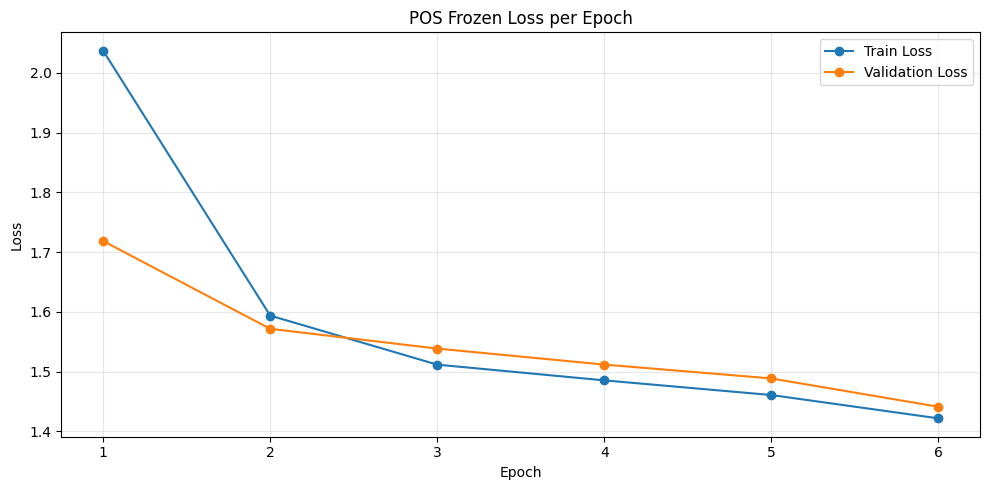

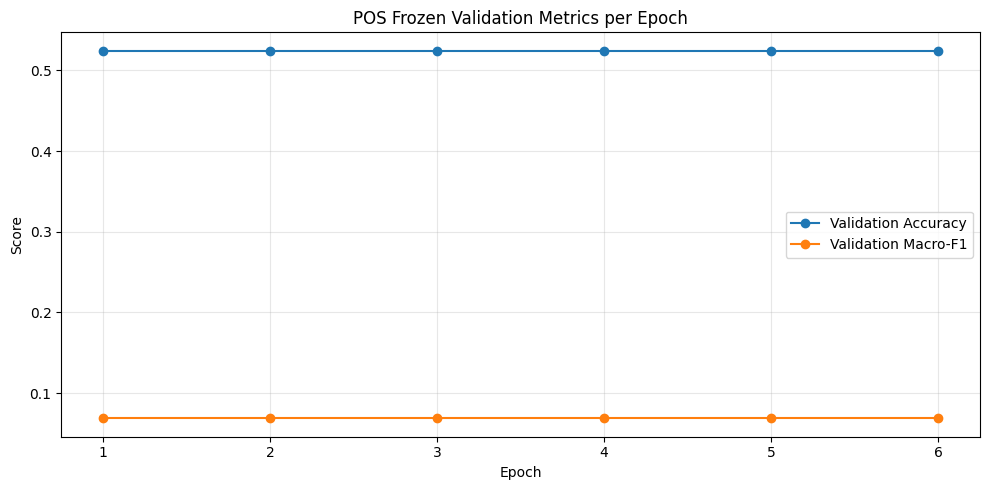

In [112]:
plot_training_history(pos_frozen_result["history"], title_prefix="POS Frozen")

## Train POS model with fine-tuned embeddings

In [113]:
pos_tuned_result = train_sequence_tagger(
    model=pos_model_tuned,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("Best fine-tuned validation Macro-F1:", pos_tuned_result["best_val_f1"])
print("Best fine-tuned epoch:", pos_tuned_result["best_epoch"])

Epoch 01 | train_loss=2.0924 | val_loss=1.7300 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.5858 | val_loss=1.5640 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5054 | val_loss=1.5292 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.4640 | val_loss=1.4860 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.3879 | val_loss=1.3947 | val_acc=0.5255 | val_macro_f1=0.0706
Epoch 06 | train_loss=1.2300 | val_loss=1.2033 | val_acc=0.5956 | val_macro_f1=0.1263
Epoch 07 | train_loss=0.9498 | val_loss=0.8799 | val_acc=0.7123 | val_macro_f1=0.2027
Epoch 08 | train_loss=0.7081 | val_loss=0.7177 | val_acc=0.7667 | val_macro_f1=0.3283
Epoch 09 | train_loss=0.5274 | val_loss=0.5764 | val_acc=0.8071 | val_macro_f1=0.4236
Epoch 10 | train_loss=0.3703 | val_loss=0.4679 | val_acc=0.8228 | val_macro_f1=0.4388
Epoch 11 | train_loss=0.2612 | val_loss=0.4590 | val_acc=0.8345 | val_macro_f1=0.4795
Epoch 12 | train_loss=0.1966 | val_loss=0.4326 | val_a

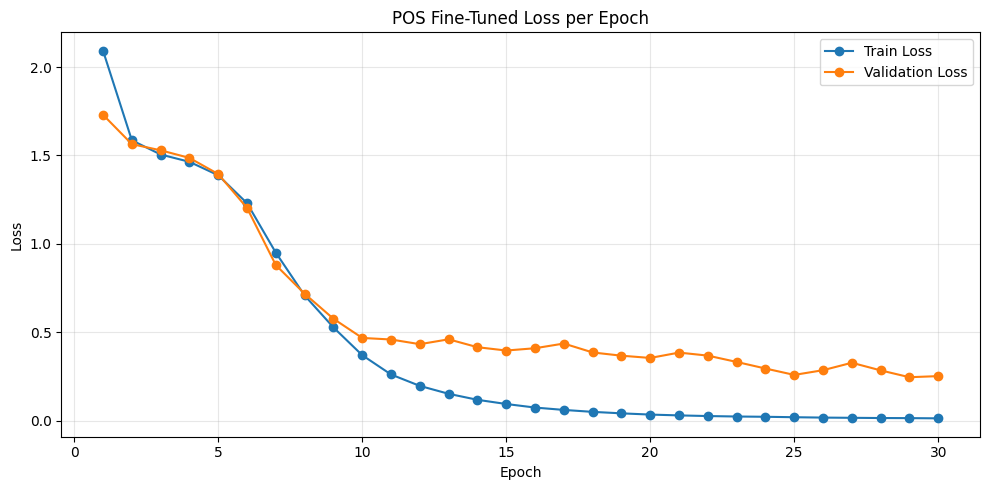

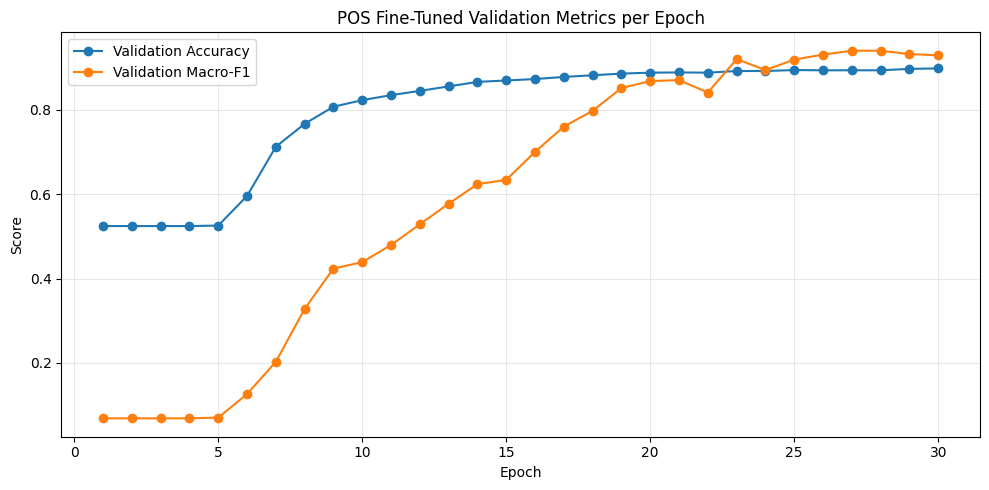

In [114]:
plot_training_history(pos_tuned_result["history"], title_prefix="POS Fine-Tuned")

## Compare frozen vs fine-tuned POS on validation

In [115]:
pos_val_summary = pd.DataFrame([
    {
        "Mode": "Frozen",
        "Best_Val_Macro_F1": pos_frozen_result["best_val_f1"],
        "Best_Epoch": pos_frozen_result["best_epoch"]
    },
    {
        "Mode": "Fine-Tuned",
        "Best_Val_Macro_F1": pos_tuned_result["best_val_f1"],
        "Best_Epoch": pos_tuned_result["best_epoch"]
    }
])

print("POS validation summary")
display(pos_val_summary)

POS validation summary


,Mode,Best_Val_Macro_F1,Best_Epoch
0,Frozen,0.068801,1
1,Fine-Tuned,0.939828,27


## Evaluate best POS frozen model on test set

In [116]:
pos_test_frozen = evaluate_sequence_tagger(
    model=pos_frozen_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("Frozen POS Test Accuracy :", pos_test_frozen["accuracy"])
print("Frozen POS Test Macro-F1 :", pos_test_frozen["macro_f1"])

Frozen POS Test Accuracy : 0.5549972082635399
Frozen POS Test Macro-F1 : 0.07138240574506284


## Evaluate best POS fine-tuned model on test set

In [117]:
pos_test_tuned = evaluate_sequence_tagger(
    model=pos_tuned_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("Fine-Tuned POS Test Accuracy :", pos_test_tuned["accuracy"])
print("Fine-Tuned POS Test Macro-F1 :", pos_test_tuned["macro_f1"])

Fine-Tuned POS Test Accuracy : 0.887213847012842
Fine-Tuned POS Test Macro-F1 : 0.9362674383466443


## POS frozen vs fine-tuned summary table

In [118]:
pos_test_summary = pd.DataFrame([
    {
        "Mode": "Frozen",
        "Test_Accuracy": pos_test_frozen["accuracy"],
        "Test_Macro_F1": pos_test_frozen["macro_f1"]
    },
    {
        "Mode": "Fine-Tuned",
        "Test_Accuracy": pos_test_tuned["accuracy"],
        "Test_Macro_F1": pos_test_tuned["macro_f1"]
    }
])

print("POS test summary")
display(pos_test_summary)

POS test summary


,Mode,Test_Accuracy,Test_Macro_F1
0,Frozen,0.554997,0.071382
1,Fine-Tuned,0.887214,0.936267


## Confusion matrix for best POS model

In [119]:
best_pos_test = pos_test_tuned if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else pos_test_frozen
best_pos_model = pos_tuned_result["model"] if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else pos_frozen_result["model"]
best_mode = "Fine-Tuned" if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else "Frozen"

cm, labels = get_confusion_matrix(
    best_pos_test["gold_ids"],
    best_pos_test["pred_ids"],
    idx2pos
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(f"Confusion matrix for best POS model ({best_mode})")
display(cm_df)

Confusion matrix for best POS model (Fine-Tuned)


,NOUN,VERB,ADJ,ADV,PRON,DET,CONJ,POST,NUM,PUNC,UNK
NOUN,796,1,197,0,0,0,0,0,0,0,0
VERB,0,128,3,0,0,0,0,0,0,0,0
ADJ,0,0,142,0,0,0,0,0,0,0,0
ADV,0,0,0,12,0,0,0,0,0,0,0
PRON,0,0,0,0,133,0,0,0,0,0,0
DET,0,0,0,0,0,15,0,0,0,0,0
CONJ,0,0,0,0,0,0,69,0,0,0,0
POST,0,0,0,0,0,0,0,258,0,0,0
NUM,0,0,0,0,0,0,0,0,31,0,0
PUNC,0,0,0,0,0,0,0,0,0,0,0


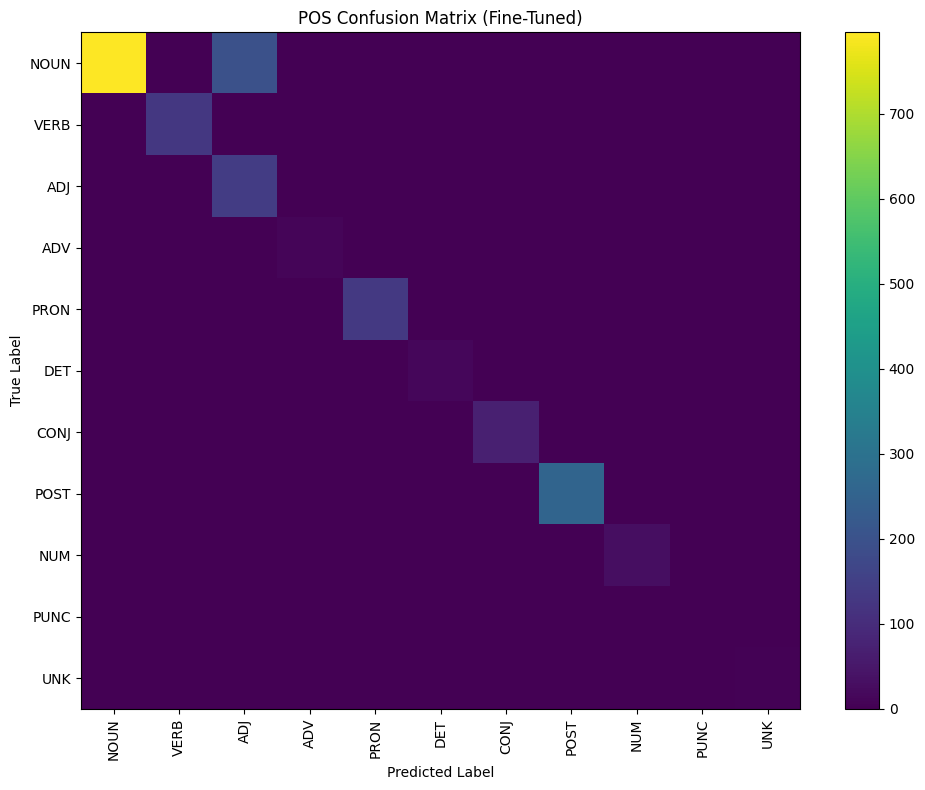

In [120]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(cm, aspect="auto")
plt.title(f"POS Confusion Matrix ({best_mode})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

In [121]:
top_confusions = get_most_confused_pairs(cm, labels, top_k=3)

confusion_df = pd.DataFrame(top_confusions, columns=["Gold_Tag", "Pred_Tag", "Count"])
print("Top 3 most confused POS tag pairs")
display(confusion_df)

Top 3 most confused POS tag pairs


,Gold_Tag,Pred_Tag,Count
0,NOUN,ADJ,197
1,VERB,ADJ,3
2,NOUN,VERB,1


In [122]:
for gold_tag, pred_tag, count in top_confusions:
    print("\n" + "=" * 80)
    print(f"Confusion pair: {gold_tag} -> {pred_tag} | Count: {count}")
    print("=" * 80)

    examples = collect_confusion_examples(
        model=best_pos_model,
        dataloader=pos_test_loader,
        device=DEVICE,
        idx2label=idx2pos,
        target_gold=gold_tag,
        target_pred=pred_tag,
        max_examples=2
    )

    if not examples:
        print("No example sentences found.")
        continue

    for ex_idx, ex in enumerate(examples, start=1):
        print(f"\nExample {ex_idx}")
        print("Tokens      :", " ".join(ex["tokens"]))
        print("Gold labels :", " ".join(ex["gold_labels"]))
        print("Pred labels :", " ".join(ex["pred_labels"]))
        print("Mismatch positions:", ex["mismatch_positions"])


Confusion pair: NOUN -> ADJ | Count: 197

Example 1
Tokens      : دوسری جانب، امریکہ کے پاکستان سے سرد تعلق مسلسل بہتر ہو جا رہے ہیں۔
Gold labels : ADJ NOUN NOUN POST NOUN POST NOUN NOUN NOUN NOUN VERB VERB VERB NOUN
Pred labels : ADJ ADJ NOUN POST NOUN POST ADJ NOUN NOUN NOUN VERB VERB VERB NOUN
Mismatch positions: [1, 6]

Example 2
Tokens      : اس کے بعد اس نے کمرے کو تالا لگا دیا اور شور مچایا تاکہ یہ ایک حادثا اگ لگنے کا واقعہ معلوم ہو۔
Gold labels : PRON POST POST PRON NOUN NOUN POST NOUN VERB VERB CONJ NOUN NOUN NOUN PRON DET NOUN NOUN NOUN POST NOUN NOUN NOUN
Pred labels : PRON POST POST PRON NOUN ADJ POST ADJ VERB VERB CONJ NOUN ADJ NOUN PRON DET ADJ NOUN NOUN POST NOUN NOUN NOUN
Mismatch positions: [5, 7, 12, 16]

Confusion pair: VERB -> ADJ | Count: 3

Example 1
Tokens      : مگر ہم یہ سمجھنے کی بھی ضرورت ہے کہ ماضی کی کارکردگی مستقبل کی عکاسی نہ کرتی۔
Gold labels : CONJ PRON PRON NOUN POST ADJ NOUN VERB CONJ ADJ POST VERB NOUN POST ADJ NOUN NOUN
Pred labels : CONJ PRON PRO

## POS classification report for best model

In [123]:
from sklearn.metrics import classification_report

gold_labels = [idx2pos[i] for i in best_pos_test["gold_ids"]]
pred_labels = [idx2pos[i] for i in best_pos_test["pred_ids"]]

pos_report = classification_report(gold_labels, pred_labels, zero_division=0)
print("POS classification report")
print(pos_report)

POS classification report
              precision    recall  f1-score   support

         ADJ       0.42      1.00      0.59       142
         ADV       1.00      1.00      1.00        12
        CONJ       0.99      1.00      0.99        69
         DET       1.00      1.00      1.00        15
        NOUN       1.00      0.80      0.89       994
         NUM       1.00      1.00      1.00        31
        POST       1.00      1.00      1.00       258
        PRON       1.00      1.00      1.00       133
         UNK       1.00      0.83      0.91         6
        VERB       0.99      0.98      0.98       131

    accuracy                           0.89      1791
   macro avg       0.94      0.96      0.94      1791
weighted avg       0.95      0.89      0.90      1791

